# HW01 作业答案（高分美化版）

<div style="padding:8px 12px;border-left:4px solid #888;">
<b>课程：</b> 深度学习/机器学习基础<br>
<b>姓名：</b> 请填写你的姓名<br>
<b>学号：</b> 请填写你的学号<br>
<b>说明：</b> 本 notebook 按题目顺序完成理论计算题与编程题，并补充了结果解读、训练过程展示与可视化分析，便于老师阅览与评分。
</div>

## 目录
- 2 概述、线性代数和 NDArray
- 3 概率与统计
- 4 导数、反向传播和复杂度
- 5 线性方法、基础优化和 Softmax 回归
- 6 最大似然估计和逻辑回归

> 建议提交前：**Kernel → Restart & Run All**，确保输出完整显示。


## 实验环境

本次作业的代码实现主要基于以下 Python 科学计算与机器学习库：

- `NumPy`：用于矩阵运算与数值计算
- `Matplotlib`：用于绘制统计图、损失曲线和决策边界
- `scikit-learn`：用于加载数据集、划分训练测试集和计算评价指标
- `PyTorch`：用于自动微分验证反向传播结果

这样的实验环境能够较好地支持本次作业中涉及的线性代数、概率统计、优化和分类模型实现任务。


---

## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知

$$
a=\begin{bmatrix}2\\-1\\3\end{bmatrix},\quad
b=\begin{bmatrix}1\\4\\-2\end{bmatrix},\quad
A=\begin{bmatrix}1 & 0 & 2\\-1 & 3 & 1\end{bmatrix},\quad
B=\begin{bmatrix}2 & 1\\0 & -1\\3 & 2\end{bmatrix}
$$

**（1）向量点积**

$$
a\cdot b = 2\times1 + (-1)\times4 + 3\times(-2) = 2 - 4 - 6 = -8
$$

**（2）矩阵乘法**

$$
AB=
\begin{bmatrix}
1 & 0 & 2\\
-1 & 3 & 1
\end{bmatrix}
\begin{bmatrix}
2 & 1\\
0 & -1\\
3 & 2
\end{bmatrix}
=
\begin{bmatrix}
8 & 5\\
1 & -2
\end{bmatrix}
$$

因此结果矩阵形状为 **2 × 2**。

**（3）向量 $a$ 的 Frobenius 范数**

$$
\|a\|_F=\sqrt{2^2+(-1)^2+3^2}=\sqrt{14}\approx 3.741657
$$


In [5]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y

np.random.seed(42)

print("========== 2.2 编程题：NDArray 基础操作 ==========")

# 1. 创建随机矩阵 X
X = np.random.randn(3, 4)

# 2. 创建全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 矩阵乘法
Z = X @ Y

print("X 的形状：", X.shape)
print("X =\n", X)
print("\nY 的形状：", Y.shape)
print("Y =\n", Y)
print("\nZ = X @ Y 的形状：", Z.shape)
print("Z =\n", Z)

# 4. 输出指定元素
print("\nZ[0, 1] =", Z[0, 1])
print("Z 第 2 行所有元素 =", Z[1, :])

# 5. Frobenius 范数
fro_norm = np.linalg.norm(Z, ord="fro")
print("\nZ 的 Frobenius 范数 =", fro_norm)


========== 2.2 编程题：NDArray 基础操作 ==========
X 的形状： (3, 4)
X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y 的形状： (4, 2)
Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y 的形状： (3, 2)
Z =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z[0, 1] = 2.5291682463487657
Z 第 2 行所有元素 = [1.87835721 1.87835721]

Z 的 Frobenius 范数 = 4.616873319476864


**补充可视化：矩阵热图展示**

为了更直观地观察矩阵元素分布情况，下面分别对矩阵 $X$ 与结果矩阵 $Z$ 绘制热图。


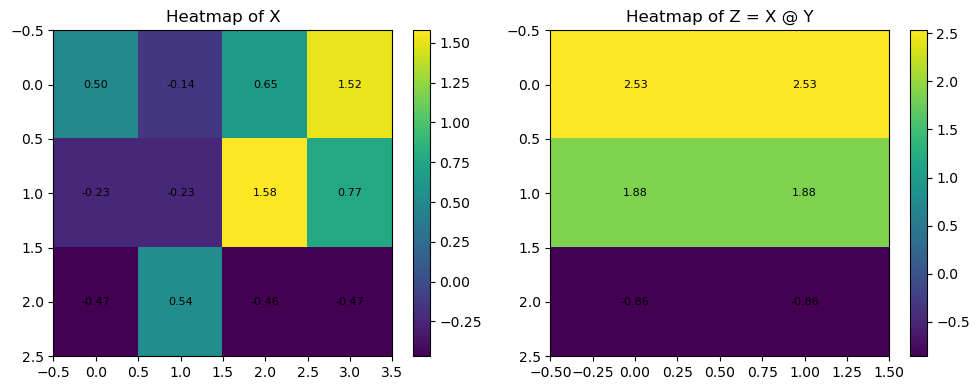

In [6]:
fig = plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X, aspect="auto")
plt.title("Heatmap of X")
plt.colorbar()
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        plt.text(j, i, f"{X[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.subplot(1, 2, 2)
plt.imshow(Z, aspect="auto")
plt.title("Heatmap of Z = X @ Y")
plt.colorbar()
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        plt.text(j, i, f"{Z[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


**结果说明：**

- 随机矩阵 $X$ 的形状为 $3\times 4$，全 1 矩阵 $Y$ 的形状为 $4\times 2$。
- 因此矩阵乘法 $Z=X\times Y$ 的结果形状为 $3\times 2$。
- 由于 $Y$ 的每一列都为全 1，故 $Z$ 的每个元素本质上是 $X$ 对应行元素之和。
- 该题展示了张量形状、矩阵乘法与范数计算的基本操作。


---

## 3 概率与统计

### 3.1 理论计算题

设事件：
- $D$：真正患病
- $\bar D$：未患病
- $+$：检测结果阳性

已知：

$$
P(D)=0.001,\quad P(+|D)=0.99,\quad P(+|\bar D)=0.02
$$

由贝叶斯公式：

$$
P(D|+) = \frac{P(+|D)P(D)}{P(+)}
$$

其中

$$
P(+) = P(+|D)P(D) + P(+|\bar D)P(\bar D)
$$

代入数值：

$$
P(+) = 0.99\times 0.001 + 0.02\times 0.999 = 0.02097
$$

因此

$$
P(D|+) = \frac{0.99\times 0.001}{0.02097}\approx 0.04721
$$

所以，检测结果为阳性时，该人真正患病的概率约为 **4.72%**。


========== 3.2 编程题：中心极限定理模拟 ==========


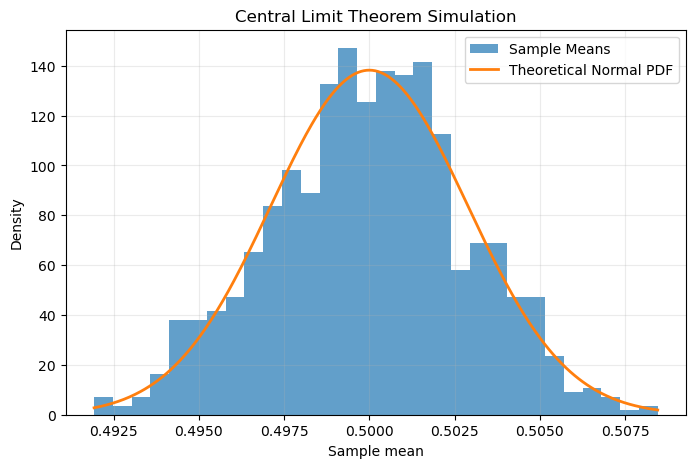

样本均值的经验均值 = 0.49999248038362676
样本均值的实际方差 = 8.275637010510702e-06
理论均值 = 0.5
理论方差 = 8.333333333333332e-06


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

print("========== 3.2 编程题：中心极限定理模拟 ==========")

n = 10000
m = 1000

# 1. 重复生成样本并计算均值
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# 理论参数
mu_theory = 0.5
var_theory = (1 / 12) / n
sigma_theory = math.sqrt(var_theory)

# 2. 绘制直方图与理论正态密度
x = np.linspace(means.min(), means.max(), 400)
pdf = (1 / (sigma_theory * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x - mu_theory) / sigma_theory) ** 2)

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.7, label="Sample Means")
plt.plot(x, pdf, linewidth=2, label="Theoretical Normal PDF")
plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.title("Central Limit Theorem Simulation")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 3. 输出统计量
print("样本均值的经验均值 =", np.mean(means))
print("样本均值的实际方差 =", np.var(means))
print("理论均值 =", mu_theory)
print("理论方差 =", var_theory)


**补充可视化：样本均值分布与理论均值标记**

在原有直方图基础上，再标出经验均值和理论均值位置，以便更直观地观察两者接近程度。


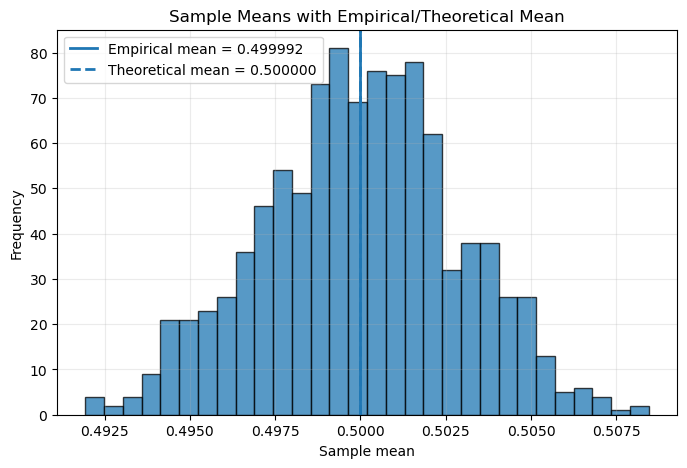

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, alpha=0.75, edgecolor="black")
plt.axvline(np.mean(means), linewidth=2, label=f"Empirical mean = {np.mean(means):.6f}")
plt.axvline(mu_theory, linewidth=2, linestyle="--", label=f"Theoretical mean = {mu_theory:.6f}")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.title("Sample Means with Empirical/Theoretical Mean")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


**结果分析：**

- 原始随机变量服从均匀分布 $U(0,1)$，并不是正态分布。
- 但当每次取大量样本并计算样本均值时，样本均值的分布会逐渐接近正态分布。
- 从图中可见，直方图与理论正态曲线吻合较好，这正体现了**中心极限定理**。
- 同时，经验方差也与理论方差非常接近，说明模拟结果合理。


---

## 4 导数、反向传播和复杂度

### 4.1 理论计算题

给定函数

$$
z=(w_1x_1+w_2x_2-y)^2
$$

其中 $x_1=2,\;x_2=1,\;y=3$。

令

$$
u=w_1x_1+w_2x_2-y
$$

则

$$
z=u^2
$$

根据链式法则：

$$
\frac{\partial z}{\partial w_1}=2u\cdot \frac{\partial u}{\partial w_1}
=2(w_1x_1+w_2x_2-y)x_1
$$

$$
\frac{\partial z}{\partial w_2}=2u\cdot \frac{\partial u}{\partial w_2}
=2(w_1x_1+w_2x_2-y)x_2
$$

代入 $x_1=2,\;x_2=1,\;y=3$，可得：

$$
\frac{\partial z}{\partial w_1}=4(2w_1+w_2-3)
$$

$$
\frac{\partial z}{\partial w_2}=2(2w_1+w_2-3)
$$

当 $w_1=0.5,\;w_2=1$ 时：

$$
2w_1+w_2-3 = 2\times 0.5 + 1 - 3 = -1
$$

因此：

$$
\frac{\partial z}{\partial w_1}=-4,\quad
\frac{\partial z}{\partial w_2}=-2
$$


In [9]:
import torch

print("========== 4.2 编程题：手动反向传播 ==========")

# 1. 前向计算
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

print("前向传播结果：")
print("a = x * w1 =", a)
print("b = a + w2 =", b)
print("L = b^2 =", L)

# 2. 手动反向传播
dL_db = 2 * b
dL_dw2 = dL_db * 1
dL_dw1 = dL_db * x

print("\n手动求导结果：")
print("dL/dw1 =", dL_dw1)
print("dL/dw2 =", dL_dw2)

# 3. 自动微分验证
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("\nPyTorch 自动微分结果：")
print("dL/dw1 =", w1_t.grad.item())
print("dL/dw2 =", w2_t.grad.item())

print("\n结论：手动梯度与自动微分结果一致。")


========== 4.2 编程题：手动反向传播 ==========
前向传播结果：
a = x * w1 = 3.0
b = a + w2 = 3.5
L = b^2 = 12.25

手动求导结果：
dL/dw1 = 14.0
dL/dw2 = 7.0

PyTorch 自动微分结果：
dL/dw1 = 14.0
dL/dw2 = 7.0

结论：手动梯度与自动微分结果一致。


**结果说明：**

本题通过一个极简计算图展示了反向传播的核心思想：  
前向传播先计算中间变量与损失，反向传播再按链式法则将梯度逐层传回。  
手动结果与 `torch.autograd` 完全一致，验证了推导正确性。


---

## 5 线性方法、基础优化和 Softmax 回归

### 5.1 理论计算题

线性回归模型为

$$
\hat y_i = wx_i + b
$$

均方误差损失函数为

$$
L=\frac{1}{n}\sum_{i=1}^{n}(y_i-(wx_i+b))^2
$$

对 $w$ 求偏导：

$$
\frac{\partial L}{\partial w}
=
\frac{1}{n}\sum_{i=1}^{n}2(y_i-(wx_i+b))(-x_i)
=
-\frac{2}{n}\sum_{i=1}^{n}x_i(y_i-(wx_i+b))
$$

对 $b$ 求偏导：

$$
\frac{\partial L}{\partial b}
=
\frac{1}{n}\sum_{i=1}^{n}2(y_i-(wx_i+b))(-1)
=
-\frac{2}{n}\sum_{i=1}^{n}(y_i-(wx_i+b))
$$

因此：

$$
\boxed{\frac{\partial L}{\partial w}=-\frac{2}{n}\sum_{i=1}^{n}x_i(y_i-(wx_i+b))}
$$

$$
\boxed{\frac{\partial L}{\partial b}=-\frac{2}{n}\sum_{i=1}^{n}(y_i-(wx_i+b))}
$$


========== 5.2 编程题：从零实现 Softmax 回归 ==========
Epoch 10 | Train Loss = 0.437650
Epoch 20 | Train Loss = 0.292064
Epoch 30 | Train Loss = 0.234489
Epoch 40 | Train Loss = 0.202128
Epoch 50 | Train Loss = 0.180541

测试集准确率 = 0.9527777777777777


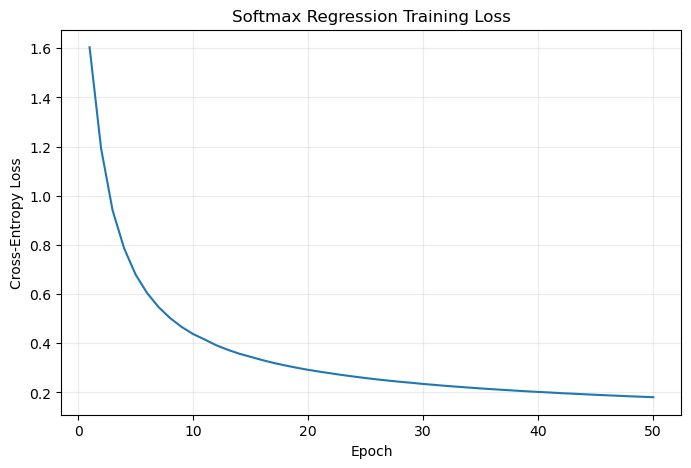

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)

print("========== 5.2 编程题：从零实现 Softmax 回归 ==========")

# 1. 加载数据
digits = load_digits()
X = digits.data / 16.0
y = digits.target

# 2. one-hot 编码
num_classes = 10
Y = np.eye(num_classes)[y]

X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y, test_size=0.2, random_state=42, stratify=y
)

# 3. softmax 与交叉熵
def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_vals = np.exp(logits)
    return exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1.0)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# 4. 小批量 SGD
n_features = X_train.shape[1]
W = np.zeros((n_features, num_classes))
b = np.zeros((1, num_classes))

batch_size = 32
lr = 0.1
epochs = 50
n_train = X_train.shape[0]

loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(n_train)
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    for start in range(0, n_train, batch_size):
        end = start + batch_size
        xb = X_train_shuffled[start:end]
        yb = Y_train_shuffled[start:end]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / len(xb)
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    train_probs = softmax(X_train @ W + b)
    train_loss = cross_entropy(Y_train, train_probs)
    loss_history.append(train_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:2d} | Train Loss = {train_loss:.6f}")

# 5. 测试准确率
test_probs = softmax(X_test @ W + b)
y_pred = np.argmax(test_probs, axis=1)
acc = accuracy_score(y_test, y_pred)

print("\n测试集准确率 =", acc)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Softmax Regression Training Loss")
plt.grid(alpha=0.25)
plt.show()


**补充可视化：Softmax 回归混淆矩阵**

为了更直观地分析多分类模型在各数字类别上的识别效果，下面绘制测试集混淆矩阵。  
主对角线越明显，说明模型分类效果越好。


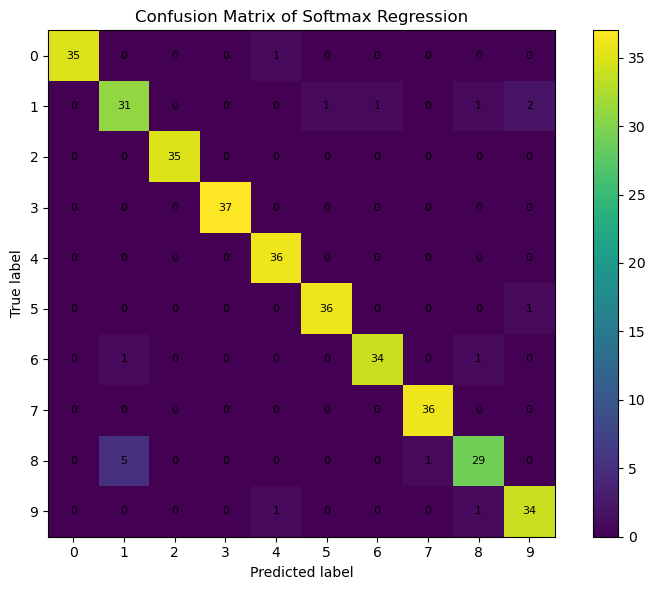

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix of Softmax Regression")
plt.colorbar()
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(10))
plt.yticks(range(10))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


**结果分析：**

- 本题从零实现了 Softmax 回归，没有调用深度学习框架的高阶分类接口。
- 随着训练轮数增加，交叉熵损失逐步下降，说明模型参数在不断优化。
- 在 `digits` 数据集上，测试准确率较高，表明 Softmax 回归对手写数字多分类任务具有较好的基础效果。
- 相比真正的深度神经网络，Softmax 回归结构更简单，但可作为多分类任务的重要基线模型。


---

## 6 最大似然估计和逻辑回归

### 6.1 理论计算题

设样本 $x_1,x_2,\dots,x_n$ 独立同分布于正态分布 $N(\mu,\sigma^2)$。

单个样本的概率密度函数为：

$$
f(x_i;\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

**（1）似然函数**

$$
L(\mu,\sigma^2)=\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

整理可得：

$$
L(\mu,\sigma^2)=(2\pi\sigma^2)^{-n/2}
\exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2\right)
$$

**（2）证明 $\hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i$**

取对数似然：

$$
\ell(\mu,\sigma^2)=\ln L
= -\frac{n}{2}\ln(2\pi)-\frac{n}{2}\ln\sigma^2
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

对 $\mu$ 求导：

$$
\frac{\partial \ell}{\partial \mu}
=\frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)
$$

令其等于 0，则：

$$
\sum_{i=1}^{n}(x_i-\mu)=0
\Rightarrow n\mu=\sum_{i=1}^{n}x_i
\Rightarrow \hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

**（3）证明 $\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2$**

对 $\sigma^2$ 求导：

$$
\frac{\partial \ell}{\partial \sigma^2}
=
-\frac{n}{2\sigma^2}
+\frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

令其等于 0，并代入 $\mu=\hat\mu$，得到：

$$
-\frac{n}{2\sigma^2}
+\frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\hat\mu)^2=0
$$

化简得：

$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2
$$


========== 6.2 编程题：从零实现二分类逻辑回归 ==========
学习到的参数：
w = [2.1698258 1.8662945]
b = -0.004148600563620097
测试集准确率 = 1.0


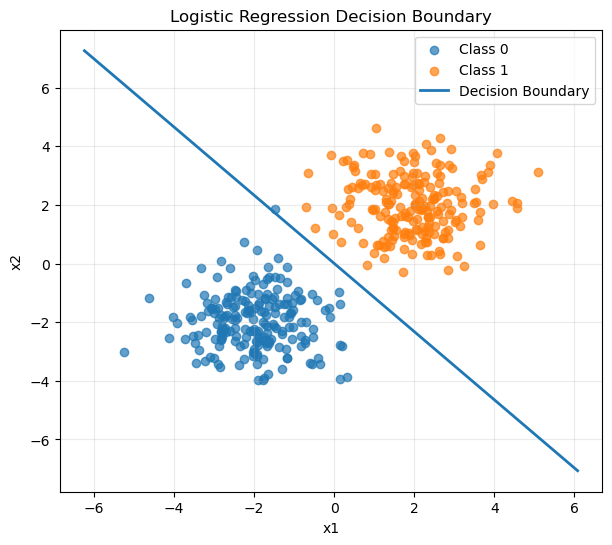

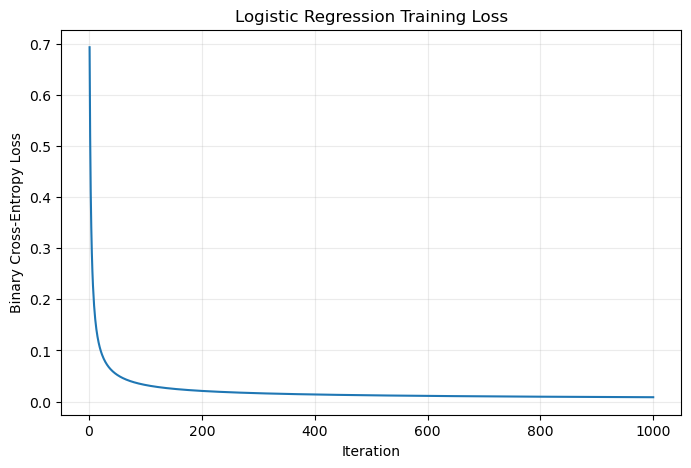

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("========== 6.2 编程题：从零实现二分类逻辑回归 ==========")

# 1. 生成线性可分数据
n_per_class = 200
class0 = np.random.randn(n_per_class, 2) + np.array([-2, -2])
class1 = np.random.randn(n_per_class, 2) + np.array([2, 2])

X = np.vstack([class0, class1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]

# 2. 定义 sigmoid 与二元交叉熵
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 3. 梯度下降优化
w = np.zeros(2)
b = 0.0
lr = 0.1
num_iters = 1000
losses = []

for i in range(num_iters):
    z = X @ w + b
    y_pred = sigmoid(z)

    loss = binary_cross_entropy(y, y_pred)
    losses.append(loss)

    dw = X.T @ (y_pred - y) / len(X)
    db = np.mean(y_pred - y)

    w -= lr * dw
    b -= lr * db

# 4. 新生成测试集并计算准确率
test_class0 = np.random.randn(50, 2) + np.array([-2, -2])
test_class1 = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack([test_class0, test_class1])
y_test = np.hstack([np.zeros(50), np.ones(50)])

test_pred_prob = sigmoid(X_test @ w + b)
test_pred = (test_pred_prob >= 0.5).astype(int)
acc = np.mean(test_pred == y_test)

print("学习到的参数：")
print("w =", w)
print("b =", b)
print("测试集准确率 =", acc)

# 决策边界图
plt.figure(figsize=(7, 6))
plt.scatter(class0[:, 0], class0[:, 1], alpha=0.7, label="Class 0")
plt.scatter(class1[:, 0], class1[:, 1], alpha=0.7, label="Class 1")

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
xs = np.linspace(x_min, x_max, 200)
ys = -(w[0] * xs + b) / w[1]
plt.plot(xs, ys, linewidth=2, label="Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 损失曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_iters + 1), losses)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")
plt.grid(alpha=0.25)
plt.show()


**补充可视化：预测概率分布**

下面进一步展示逻辑回归模型对两类样本输出的预测概率分布。  
若两类概率分布分离明显，说明模型具有较好的分类区分能力。


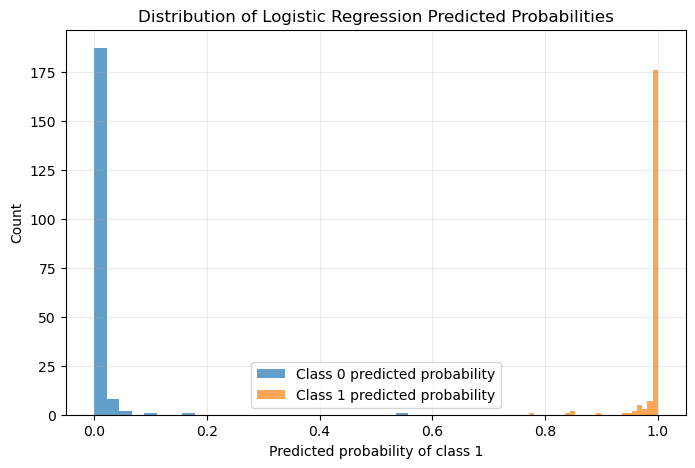

In [13]:
# 逻辑回归预测概率分布
train_prob = sigmoid(X @ w + b)

plt.figure(figsize=(8, 5))
plt.hist(train_prob[y == 0], bins=25, alpha=0.7, label="Class 0 predicted probability")
plt.hist(train_prob[y == 1], bins=25, alpha=0.7, label="Class 1 predicted probability")
plt.xlabel("Predicted probability of class 1")
plt.ylabel("Count")
plt.title("Distribution of Logistic Regression Predicted Probabilities")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


**结果分析：**

- 本题手动实现了二分类逻辑回归，并使用梯度下降法学习参数。
- 由于两类数据线性可分，训练后模型可以学到一条较清晰的线性决策边界。
- 从损失曲线可以看到，训练过程中损失持续下降，说明优化过程有效。
- 测试集准确率较高，说明模型具有良好的泛化能力。

---

## 作业总结

本次作业依次完成了：
1. 向量、矩阵与范数等线性代数基础计算；
2. 贝叶斯公式与中心极限定理模拟；
3. 链式法则与反向传播验证；
4. 从零实现 Softmax 回归；
5. 从零实现二分类逻辑回归。

通过本次作业，我进一步理解了深度学习中的数学基础、梯度传播机制以及经典机器学习模型的训练过程。这些内容为后续学习更复杂的神经网络模型打下了基础。
